In [1]:
# ── Cell 1: Imports & Data Loading ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://raw.githubusercontent.com/RaulSolaNavarro/CIS9660-2026-SPRING/main/data/Telco-Customer-Churn.csv"

df = pd.read_csv(URL)

print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [2]:
# ── Cell 2: Data Inspection ──────────────────────────────────────────────────
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Churn Distribution ===")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(3))

=== Data Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

In [3]:
# ── Cell 3: Data Cleaning ────────────────────────────────────────────────────

# Convert TotalCharges to numeric (some entries are empty strings)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaNs that created
print("TotalCharges NaNs after conversion:", df['TotalCharges'].isnull().sum())

# Drop those rows (they're new customers with tenure=0)
df = df.dropna(subset=['TotalCharges'])
print("Rows after dropping NaNs:", df.shape[0])

# Convert Churn to binary 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert SeniorCitizen to object for consistency in plots
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

print("\nCleaning complete!")
print(df[['TotalCharges', 'Churn', 'SeniorCitizen']].head())

TotalCharges NaNs after conversion: 11
Rows after dropping NaNs: 7032

Cleaning complete!
   TotalCharges  Churn SeniorCitizen
0         29.85      0            No
1       1889.50      0            No
2        108.15      1            No
3       1840.75      0            No
4        151.65      1            No


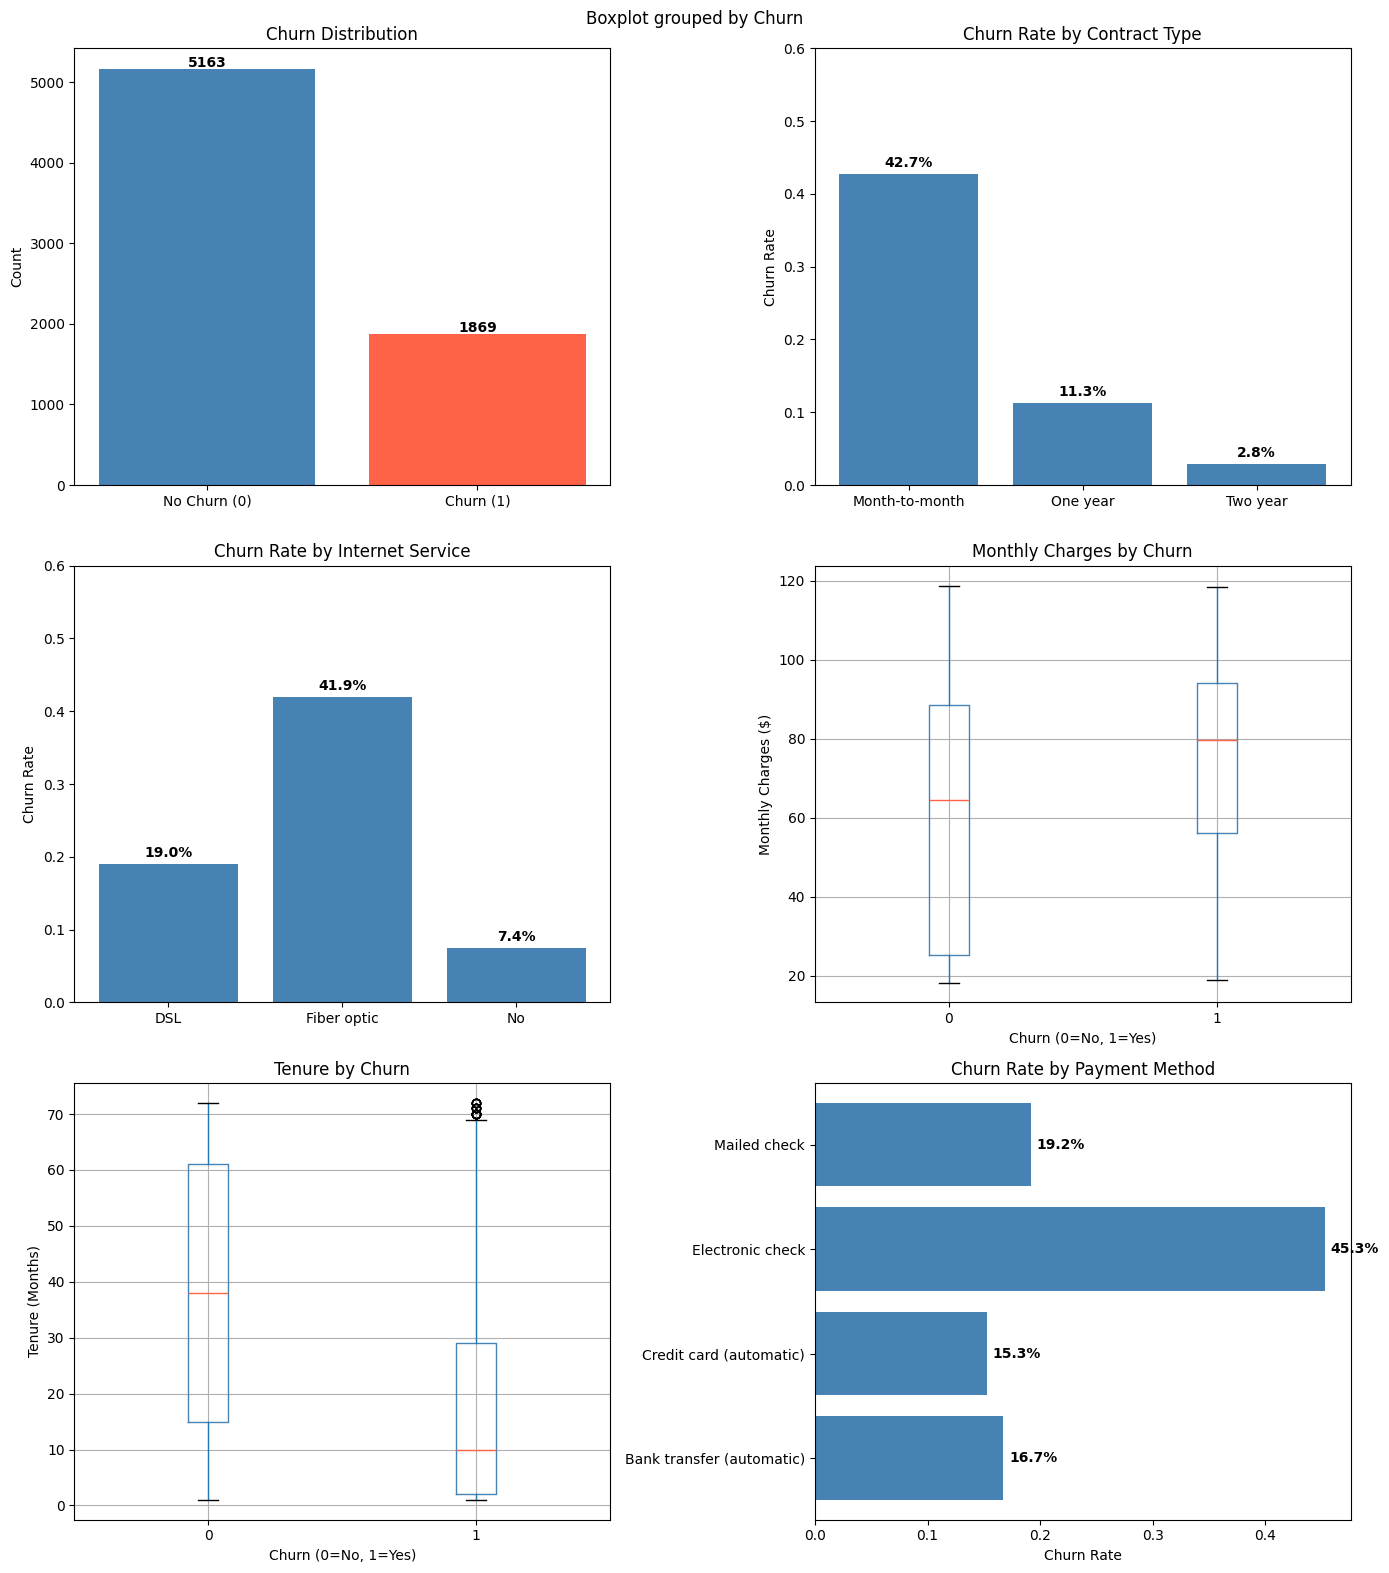

EDA plots saved!


In [4]:
# ── Cell 4: EDA ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.suptitle('Exploratory Data Analysis — Telco Customer Churn', fontsize=16, fontweight='bold')

# 1. Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0,0].bar(['No Churn (0)', 'Churn (1)'], churn_counts, color=['steelblue','tomato'])
axes[0,0].set_title('Churn Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(churn_counts):
    axes[0,0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# 2. Churn rate by Contract Type
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
axes[0,1].bar(contract_churn['Contract'], contract_churn['Churn'], color='steelblue')
axes[0,1].set_title('Churn Rate by Contract Type')
axes[0,1].set_ylabel('Churn Rate')
axes[0,1].set_ylim(0, 0.6)
for i, row in contract_churn.iterrows():
    axes[0,1].text(i, row['Churn'] + 0.01, f"{row['Churn']:.1%}", ha='center', fontweight='bold')

# 3. Churn rate by Internet Service
internet_churn = df.groupby('InternetService')['Churn'].mean().reset_index()
axes[1,0].bar(internet_churn['InternetService'], internet_churn['Churn'], color='steelblue')
axes[1,0].set_title('Churn Rate by Internet Service')
axes[1,0].set_ylabel('Churn Rate')
axes[1,0].set_ylim(0, 0.6)
for i, row in internet_churn.iterrows():
    axes[1,0].text(i, row['Churn'] + 0.01, f"{row['Churn']:.1%}", ha='center', fontweight='bold')

# 4. MonthlyCharges by Churn (Boxplot)
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1,1],
           boxprops=dict(color='steelblue'), medianprops=dict(color='tomato'))
axes[1,1].set_title('Monthly Charges by Churn')
axes[1,1].set_xlabel('Churn (0=No, 1=Yes)')
axes[1,1].set_ylabel('Monthly Charges ($)')
plt.sca(axes[1,1])
plt.title('Monthly Charges by Churn')

# 5. Tenure by Churn (Boxplot)
df.boxplot(column='tenure', by='Churn', ax=axes[2,0],
           boxprops=dict(color='steelblue'), medianprops=dict(color='tomato'))
axes[2,0].set_title('Tenure by Churn')
axes[2,0].set_xlabel('Churn (0=No, 1=Yes)')
axes[2,0].set_ylabel('Tenure (Months)')
plt.sca(axes[2,0])
plt.title('Tenure by Churn')

# 6. Churn rate by Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn'].mean().reset_index()
axes[2,1].barh(payment_churn['PaymentMethod'], payment_churn['Churn'], color='steelblue')
axes[2,1].set_title('Churn Rate by Payment Method')
axes[2,1].set_xlabel('Churn Rate')
for i, row in payment_churn.iterrows():
    axes[2,1].text(row['Churn'] + 0.005, i, f"{row['Churn']:.1%}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved!")

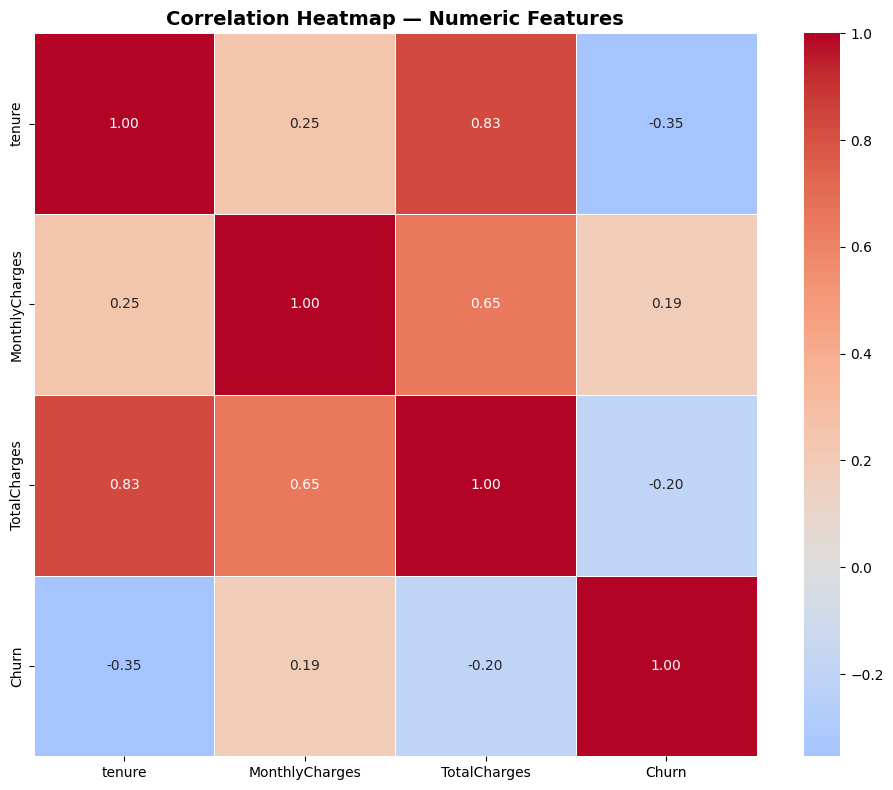

Heatmap saved!


In [5]:
# ── Cell 5: Correlation Heatmap ──────────────────────────────────────────────
# Select only numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

In [6]:
# ── Cell 6: Preprocessing ────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Drop columns we won't use
df_model = df.drop(columns=['customerID', 'TotalCharges'])

# Encode all remaining categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Define features and target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nChurn rate in train: {y_train.mean():.3f}")
print(f"Churn rate in test:  {y_test.mean():.3f}")

Categorical columns to encode: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Training set: (5625, 18)
Test set:     (1407, 18)

Churn rate in train: 0.266
Churn rate in test:  0.266


=== Baseline Logistic Regression ===
ROC-AUC:  0.8323

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1033
       Churn       0.62      0.55      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.72      0.72      1407
weighted avg       0.78      0.79      0.79      1407



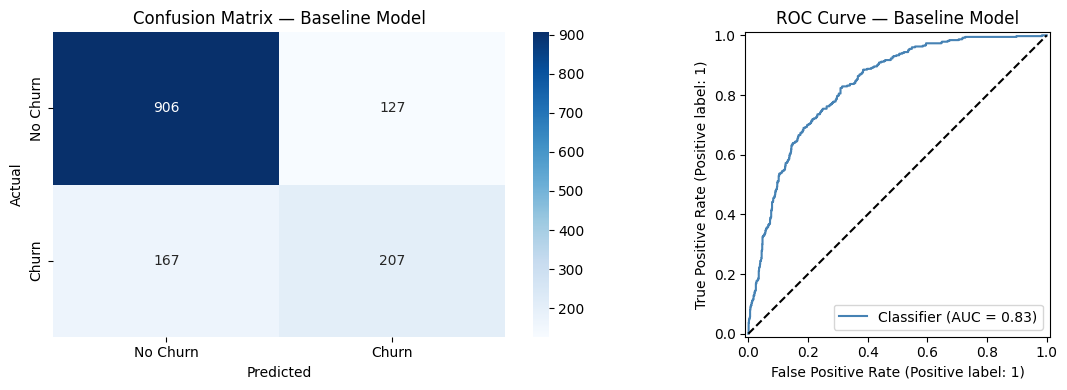

In [7]:
# ── Cell 7: Baseline Logistic Regression ─────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, RocCurveDisplay)

# Scale features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Fit baseline model
lr_base = LogisticRegression(random_state=42, max_iter=1000)
lr_base.fit(X_train_scaled, y_train)

# Predictions
y_pred  = lr_base.predict(X_test_scaled)
y_proba = lr_base.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("=== Baseline Logistic Regression ===")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Confusion matrix plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
axes[0].set_title('Confusion Matrix — Baseline Model')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color='steelblue')
axes[1].plot([0,1],[0,1], 'k--')
axes[1].set_title('ROC Curve — Baseline Model')

plt.tight_layout()
plt.savefig('baseline_model.png', dpi=150, bbox_inches='tight')
plt.show()

=== Interaction Term Model ===
ROC-AUC:  0.8324

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.86      1033
       Churn       0.63      0.56      0.59       374

    accuracy                           0.79      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



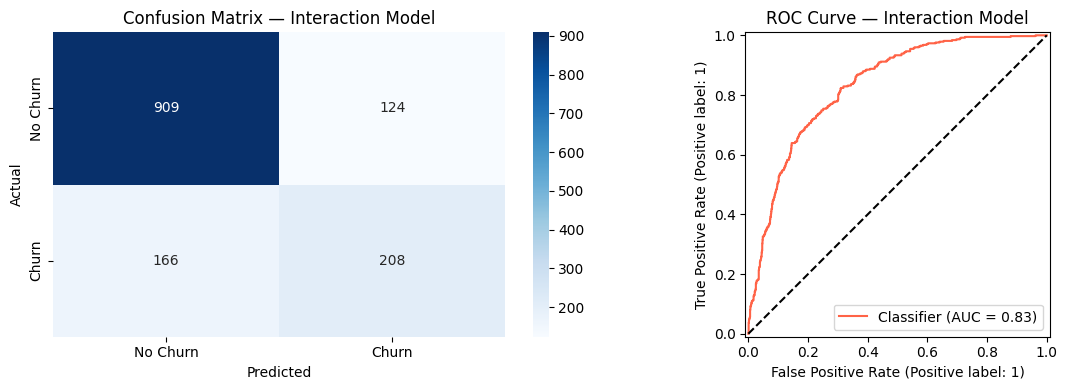

In [8]:
# ── Cell 8: Interaction Term Model ───────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

# Add interaction term: Contract × InternetService
X_train_int = X_train.copy()
X_test_int  = X_test.copy()

X_train_int['Contract_x_Internet'] = X_train['Contract'] * X_train['InternetService']
X_test_int['Contract_x_Internet']  = X_test['Contract']  * X_test['InternetService']

# Scale
scaler_int = StandardScaler()
X_train_int_scaled = scaler_int.fit_transform(X_train_int)
X_test_int_scaled  = scaler_int.transform(X_test_int)

# Fit interaction model
lr_int = LogisticRegression(random_state=42, max_iter=1000)
lr_int.fit(X_train_int_scaled, y_train)

# Predictions
y_pred_int  = lr_int.predict(X_test_int_scaled)
y_proba_int = lr_int.predict_proba(X_test_int_scaled)[:, 1]

# Metrics
print("=== Interaction Term Model ===")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_int):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_int, target_names=['No Churn', 'Churn']))

# Confusion matrix + ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_int = confusion_matrix(y_test, y_pred_int)
sns.heatmap(cm_int, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
axes[0].set_title('Confusion Matrix — Interaction Model')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

RocCurveDisplay.from_predictions(y_test, y_proba_int, ax=axes[1], color='tomato')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve — Interaction Model')

plt.tight_layout()
plt.savefig('interaction_model.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── Cell 9: Threshold Tuning + K-Fold CV ─────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score

# ── Part A: Lower classification threshold to improve churn recall ──
print("=== Threshold Tuning (Interaction Model) ===")
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]
print(f"{'Threshold':<12} {'Accuracy':<12} {'Churn Recall':<15} {'Churn Precision':<18} {'F1'}")
print("-" * 65)
for t in thresholds:
    y_pred_t = (y_proba_int >= t).astype(int)
    report = classification_report(y_test, y_pred_t,
                                   target_names=['No Churn','Churn'],
                                   output_dict=True)
    print(f"{t:<12} "
          f"{report['accuracy']:<12.3f} "
          f"{report['Churn']['recall']:<15.3f} "
          f"{report['Churn']['precision']:<18.3f} "
          f"{report['Churn']['f1-score']:.3f}")

# ── Part B: K-Fold Cross Validation ──
print("\n=== 5-Fold Cross Validation (Interaction Model) ===")
pipeline_X = np.hstack([
    scaler_int.fit_transform(X_train_int),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy':  'accuracy',
    'roc_auc':   'roc_auc',
    'recall':    make_scorer(recall_score),
    'f1':        'f1'
}

cv_results = cross_validate(
    LogisticRegression(random_state=42, max_iter=1000),
    scaler_int.fit_transform(X_train_int),
    y_train,
    cv=cv,
    scoring=scoring
)

for metric, values in cv_results.items():
    if metric.startswith('test_'):
        name = metric.replace('test_','')
        print(f"{name:<12}: {values.mean():.4f} ± {values.std():.4f}")

=== Threshold Tuning (Interaction Model) ===
Threshold    Accuracy     Churn Recall    Churn Precision    F1
-----------------------------------------------------------------
0.3          0.743        0.754           0.511              0.609
0.35         0.768        0.714           0.548              0.620
0.4          0.783        0.676           0.578              0.623
0.45         0.795        0.639           0.610              0.624
0.5          0.794        0.556           0.627              0.589

=== 5-Fold Cross Validation (Interaction Model) ===
accuracy    : 0.8021 ± 0.0108
roc_auc     : 0.8438 ± 0.0058
recall      : 0.5418 ± 0.0253
f1          : 0.5927 ± 0.0225


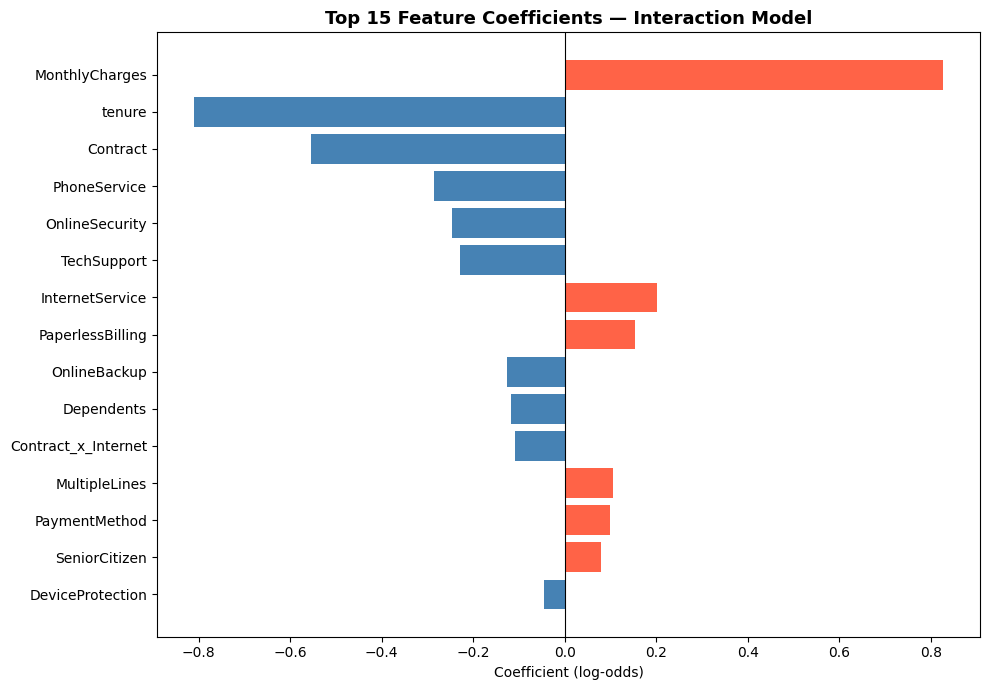


Top 10 features by absolute coefficient:
         Feature  Coefficient
  MonthlyCharges     0.825741
          tenure    -0.809430
        Contract    -0.554542
    PhoneService    -0.286200
  OnlineSecurity    -0.245810
     TechSupport    -0.228954
 InternetService     0.201053
PaperlessBilling     0.153822
    OnlineBackup    -0.127256
      Dependents    -0.117042


In [10]:
# ── Cell 10: Feature Importance ──────────────────────────────────────────────

feature_names = list(X_train_int.columns)
coefficients  = lr_int.coef_[0]

coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

plt.figure(figsize=(10, 7))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Feature Coefficients — Interaction Model',
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient (log-odds)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features by absolute coefficient:")
print(coef_df[['Feature','Coefficient']].head(10).to_string(index=False))